In [ ]:
!pip install pandas requests


In [ ]:
# =======================================
# Polling CoinGecko API -> Save to Colab
# =======================================

import time
import pandas as pd
from datetime import datetime, timezone
import requests
import os

OUTPUT_DIR = "/content/crypto_prices"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def fetch_prices():
    url = "https://api.coingecko.com/api/v3/simple/price"
    params = {
        "ids": "bitcoin,ethereum",
        "vs_currencies": "usd"
    }
    response = requests.get(url, params=params, timeout=10)
    if response.status_code == 200:
        return response.json()
    else:
        print("API error", response.status_code)
        return {}

# Gioi han so vong de tranh Colab disconnect
MAX_ROUNDS = 20
round_count = 0

while round_count < MAX_ROUNDS:
    try:
        data = fetch_prices()

        if "bitcoin" not in data or "ethereum" not in data:
            print("Missing data", data)
            time.sleep(5)
            continue

        timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S")

        record = {
            "timestamp": timestamp,
            "bitcoin_usd": data["bitcoin"]["usd"],
            "ethereum_usd": data["ethereum"]["usd"]
        }

        df = pd.DataFrame([record])

        filename = f"{OUTPUT_DIR}/crypto_prices_{datetime.now(timezone.utc).strftime('%Y-%m-%d')}.csv"

        if os.path.exists(filename):
            df.to_csv(filename, mode="a", header=False, index=False)
        else:
            df.to_csv(filename, index=False)

        print("Saved", record)

        round_count += 1

    except Exception as e:
        print("Error", e)

    time.sleep(15)


Saved {'timestamp': '2026-01-22 13:47:11', 'bitcoin_usd': 89549, 'ethereum_usd': 2966.34}
Saved {'timestamp': '2026-01-22 13:47:26', 'bitcoin_usd': 89549, 'ethereum_usd': 2966.34}
Saved {'timestamp': '2026-01-22 13:47:41', 'bitcoin_usd': 89559, 'ethereum_usd': 2967.3}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
API error 429
Missing data {}
Saved {'timestamp': '2026-01-22 13:48:56', 'bitcoin_usd': 89565, 'ethereum_usd': 2967.92}
Saved {'timestamp': '2026-01-22 13:49:11', 'bitcoin_usd': 89565, 'ethereum_usd': 2967.92}
Saved {'timestamp': '2026-01-22 13:49:27', 'bitcoin_usd': 89565, 'ethereum_usd': 2967.92}
Saved {'timestamp': '2026-01-22 13:49:42', 'bitcoin_usd': 89568, 'ethereum_usd': 2968.83}
API error 4

KeyboardInterrupt: 

In [ ]:
!pip install kafka-python pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.3/326.3 kB 6.2 MB/s eta 0:00:00


Realtime Crypto Prices from Kafka
Messages received: 20
Last update: 2026-01-22T14:17:20.067938+00:00
----------------------------------------


/tmp/ipython-input-646628773.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  filename = f"{OUTPUT_DIR}/crypto_prices_{datetime.utcnow().strftime('%Y-%m-%d')}.csv"


,timestamp,bitcoin_usd,ethereum_usd
10,2026-01-22T14:12:57.623969+00:00,89474,2970.35
11,2026-01-22T14:13:13.011185+00:00,89474,2970.35
12,2026-01-22T14:13:28.399520+00:00,89474,2970.35
13,2026-01-22T14:13:44.018058+00:00,89512,2973.37
14,2026-01-22T14:15:01.182984+00:00,89544,2975.54
15,2026-01-22T14:15:16.575072+00:00,89544,2975.54
16,2026-01-22T14:15:32.091244+00:00,89544,2975.54
17,2026-01-22T14:16:49.238060+00:00,89594,2976.72
18,2026-01-22T14:17:04.639814+00:00,89594,2976.72
19,2026-01-22T14:17:20.067938+00:00,89594,2976.72


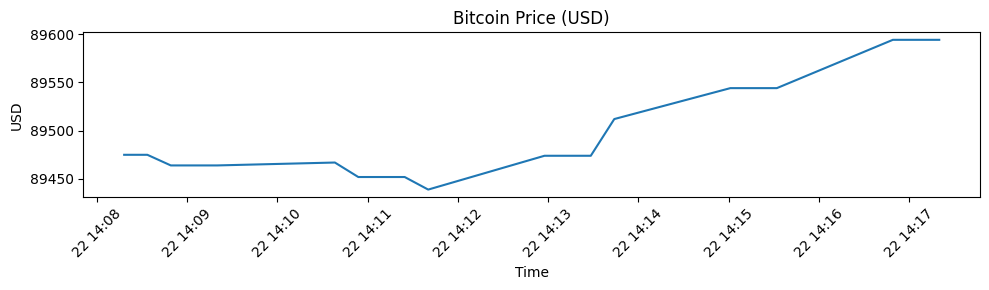

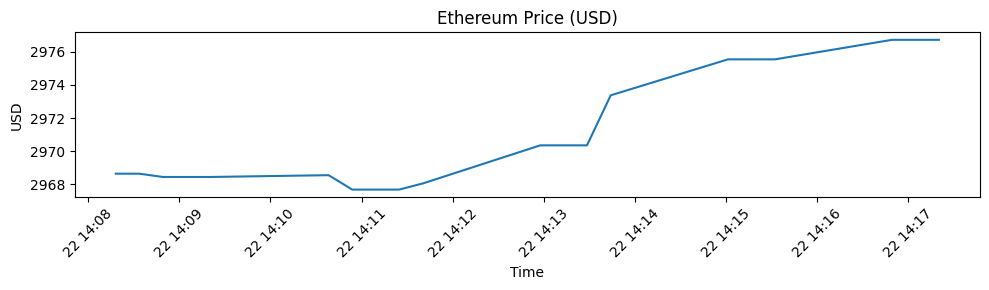

In [ ]:
# =======================================
# Kafka Consumer -> UI + 2 Realtime Charts
# Topic: crypto-prices
# =======================================

import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from kafka import KafkaConsumer
from IPython.display import display, clear_output
import os

# -------- Kafka config --------
BOOTSTRAP_SERVERS = "3.104.237.133"   # DOI LAI neu Kafka public / cloud
TOPIC_NAME = "crypto-prices"
GROUP_ID = "crypto-consumer-ui"

# -------- Output --------
OUTPUT_DIR = "/content/crypto_prices"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- History Data --------
history_df = pd.DataFrame(columns=["timestamp", "bitcoin_usd", "ethereum_usd"])

# -------- Kafka Consumer --------
consumer = KafkaConsumer(
    TOPIC_NAME,
    bootstrap_servers=BOOTSTRAP_SERVERS,
    auto_offset_reset="latest",
    enable_auto_commit=True,
    group_id=GROUP_ID,
    value_deserializer=lambda x: json.loads(x.decode("utf-8"))
)

print("Listening Kafka topic:", TOPIC_NAME)

MAX_MESSAGES = 20
msg_count = 0

for message in consumer:
    clear_output(wait=True)

    try:
        data = message.value

        record = {
            "timestamp": data["timestamp"],
            "bitcoin_usd": data["bitcoin_usd"],
            "ethereum_usd": data["ethereum_usd"]
        }

        df = pd.DataFrame([record])
        history_df = pd.concat([history_df, df], ignore_index=True)

        # ---- Save CSV ----
        filename = f"{OUTPUT_DIR}/crypto_prices_{datetime.utcnow().strftime('%Y-%m-%d')}.csv"
        if os.path.exists(filename):
            df.to_csv(filename, mode="a", header=False, index=False)
        else:
            df.to_csv(filename, index=False)

        print("Realtime Crypto Prices from Kafka")
        print("Messages received:", msg_count + 1)
        print("Last update:", record["timestamp"])
        print("-" * 40)

        # ---- Show table ----
        display(history_df.tail(10))

        plot_df = history_df.copy()
        plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"])

        # -------- Chart 1: Bitcoin --------
        plt.figure(figsize=(10, 3))
        plt.plot(plot_df["timestamp"], plot_df["bitcoin_usd"])
        plt.title("Bitcoin Price (USD)")
        plt.xlabel("Time")
        plt.ylabel("USD")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # -------- Chart 2: Ethereum --------
        plt.figure(figsize=(10, 3))
        plt.plot(plot_df["timestamp"], plot_df["ethereum_usd"])
        plt.title("Ethereum Price (USD)")
        plt.xlabel("Time")
        plt.ylabel("USD")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        msg_count += 1
        if msg_count >= MAX_MESSAGES:
            break

    except Exception as e:
        print("Error:", e)

consumer.close()
